# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt # importar librerías

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv("/datasets/users_latam.csv")
usage = pd.read_csv("/datasets/usage.csv")

In [3]:
plans.head(5) # mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
users.head(5) # mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
usage.head(5) # mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
plans.info() # inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
users.info()  # inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
usage.info() # inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum().sort_values()) # Cantidad de valores nulos
print(users.isna().mean().sort_values(ascending=False)) # Proporción de valores nulos

user_id          0
first_name       0
last_name        0
age              0
reg_date         0
plan             0
city           469
churn_date    3534
dtype: int64
churn_date    0.88350
city          0.11725
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
reg_date      0.00000
plan          0.00000
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum().sort_values()) # Cantidad de valores nulos
print(usage.isna().mean().sort_values(ascending=False)) # Proporción de valores nulos

id              0
user_id         0
type            0
date           50
length      17896
duration    22076
dtype: int64
duration    0.55190
length      0.44740
date        0.00125
id          0.00000
user_id     0.00000
type        0.00000
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción? en users las columnas churn_date con 88.35% y city con 11.72%
- en usage duration con 55.19% esto debido a que text no tiene duracion, length con un 44.74% esto debido a que calls no lleva registro y date 1.25%
- Indica qué harías: ¿imputar, eliminar, ignorar? en este caso se ignora debido que algunas de estas columnas no se usaran para el analisis y no interfiere en el mismo, otras la falta de registro esta validado por las categorias en type (duration y length) y la de city es menor al 5% y se reemplaaran por valores nulos.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
print(users[["user_id","age"]].describe()) # explorar columnas numéricas de users
print("la mediana de las columnas es:",users[["user_id","age"]].median())
print(users[["user_id"]].value_counts())
print(users[["age"]].value_counts())

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000
la mediana de las columnas es: user_id    11999.5
age           47.0
dtype: float64
user_id
10000      1
12671      1
12658      1
12659      1
12660      1
          ..
11338      1
11339      1
11340      1
11341      1
13999      1
Length: 4000, dtype: int64
age
50     86
30     81
78     79
33     74
36     74
       ..
51     54
57     54
62     51
68     51
70     45
Length: 63, dtype: int64


- La columna `user_id` ... Observamos muchas variación entre los datos, con una desviación estandar muy grande lo que indica mucha variabilidad, pero estopuede ser normal debido al tipo de dato que es
- La columna `age` ... Encontramos datos imposibles o sentinels "-999" lo cual afecta a la media o promedio, asi como la desviación estandar. tambien se observa que la mediana es mas alta que el promedio. lo cual asegura que el valor "-999" afecta este calculo, por lo cual la mediana es mas representativa que el promedio en este caso.

In [13]:
print(usage[["id", "user_id","duration","length"]].describe()) # explorar columnas numéricas de usage
print("la mediana de las columnas son las siguientes:",usage[["id", "user_id","duration","length"]].median())
print("valores unicos de duration",usage[["duration"]].value_counts())
print("valores unicos de length",usage[["length"]].value_counts())

                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000
la mediana de las columnas son las siguientes: id          20000.5
user_id     12013.0
duration        3.5
length         50.0
dtype: float64
valores unicos de duration duration
0.21        47
0.84        43
0.02        43
0.03        43
1.25        43
            ..
12.55        1
18.75        1
18.74        1
18.69        1
10.51        1
Length: 2090, dtype: int64
valores unicos de length length
47.0      460
51.0      457
53.0      456
45.0   

- Las columnas `id` y `user_id`... Se observa el mismo patron que en el dataframe de users, desviación estandar que indica mucha variabilidad, valor minimo y maximo muy alejados entre si. pero esto puede ser normal debido a que son numeros identificativos para cada usuario.
- Las columnas ... la columna duration se observa una desvación estandar baja, esto indica poca variablidad, se observa que el valor minimo no podria tomarse en cuenta, ya que las llamadas no duran "0", ademas en el cuartil 75% indica que el valor maximo hasta ese punto es "64" esto pudiese decirnos que el valor maximo puede ser un valor real pero colo comun. En la columna length se observa el mismo valor minimoque en duration lo cual no es posible, se considera un seentinel y tiene un caso similar que durataion con su cuartil 75% y su valor maximo puede ser un valor posible pero poco comun.

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print(users[columnas_user].describe())
print( )
print(users[columnas_user].value_counts())
print( )
print("valores unicos de city:",users["city"].value_counts())
print( )
print("valores unicos de plan:",users["plan"].value_counts())




          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595

city      plan   
Bogotá    Basico     522
CDMX      Basico     474
Medellín  Basico     398
GDL       Basico     298
Bogotá    Premium    286
MTY       Basico     275
Cali      Basico     262
CDMX      Premium    256
Medellín  Premium    218
Cali      Premium    162
GDL       Premium    152
MTY       Premium    132
?         Basico      65
          Premium     31
dtype: int64

valores unicos de city: Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

valores unicos de plan: Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city` ... Se detectan valores no validos "?" y este registro se repite 96 veces, ademas valores nulos los cuales cuetan con 469 registros.
- La columna `plan` ... cuenta unicamente con 2 categorias, no se encuentran registros de categorias invalidas, tapoco se encuentran valores nulos.

In [15]:
# explorar columna categórica de usage
print(usage['type'].describe()) # completa el código
print( )
print(usage["type"].value_counts())

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

text    22092
call    17908
Name: type, dtype: int64


- La columna `type` ... Cuenta con dos categorias, de las cuales predomina la categoria "text", no se encuentran categorias invalidas, ni valores nulos


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  en columna city y en columna age
- ¿Qué acción tomarías?  los convertiria en valores nulos los de la columna city y en columna age los remplazaria por la mediana para no afectar el analisis.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users["reg_date"] = pd.to_datetime(users["reg_date"],errors="coerce") # completa el código

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage["date"],errors="coerce") # completa el código

In [18]:
# Revisar los años presentes en `reg_date` de users
print(users["reg_date"].dt.year.value_counts())
print( )
print("total de registros en reg_date:",users["reg_date"].dt.year.value_counts().sum())

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

total de registros en reg_date: 4000


En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.
observamos años que no se requieren para el analisis, ya que, este nos pide centrarnos unicamente en el 2024.

In [19]:
# Revisar los años presentes en `date` de usage
print(usage["date"].dt.year.value_counts())
print( )
print("total de registros en date:",usage["date"].dt.year.value_counts().sum())

2024.0    39950
Name: date, dtype: int64

total de registros en date: 39950


En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.
Se encuentran 50 valores nulos 

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- en reg_date aparece 2026 que por las fechas del dataset no se deberian usar y en date aparecen valores nulos
- ¿Qué harías con ellas?
- Convertirlas a nulos y no considerarlos para el analsis

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users["age"].median()
users["age"] = users["age"].replace([-999],age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users["city"]=users["city"].replace(["?","NA"],pd.NA)

# Verificar cambios
print(users["city"].value_counts())
print( )
print(users["city"].value_counts().sum())

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

3435


In [22]:
# Marcar fechas futuras como NA para reg_date
users["reg_date"]=users["reg_date"].dt.year.replace([2026,"NA"],pd.NA)

# Verificar cambios
print(users["reg_date"].value_counts())

2024    1330
2023    1316
2022    1314
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby("type")["duration"].apply(lambda x: x.isna().mean()).sort_values(ascending=False).head(10)

type
text    0.999276
call    0.000000
Name: duration, dtype: float64

In [24]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby("type")["length"].apply(lambda x: x.isna().mean()).sort_values(ascending=False).head(10)

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

El 99.92% de la categoria text no tiene duración, lo cual es correcto. se deberia marcar como nulos los que tengan un registro de tiempo, pero como es tan poco el porcentaje no afectara en el analisis.

El 99.93 de la categoria call no tiene "length", lo cual es correcto debido a que las llamadas nocuentan con cierto numero de caracteres, los resgistros que tengan tiempo deberian consiederarse como nulos, pero como es tan poco el porcentaje no afectara en el analisis.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',        # Total de mensajes
    'is_call': 'sum',        # Total de llamadas  
    'duration': 'sum'        # Total de minutos de llamadas
}).reset_index()
# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Renombrar columnas
usage_agg.columns = ['user_id', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
# Resumen estadístico de las columnas numéricas

columnas_numericas_users_porfile= ["user_id","age","cant_mensajes","cant_llamadas","cant_minutos_llamada"]
print(user_profile[columnas_numericas_users_porfile].describe())
print( )
print("Mediana de las columns numericas:",user_profile[columnas_numericas_users_porfile].median())

            user_id          age  cant_mensajes  cant_llamadas  \
count   4000.000000  4000.000000    3999.000000    3999.000000   
mean   11999.500000    48.122250       5.524381       4.478120   
std     1154.844867    17.690408       2.358416       2.144238   
min    10000.000000    18.000000       0.000000       0.000000   
25%    10999.750000    33.000000       4.000000       3.000000   
50%    11999.500000    47.000000       5.000000       4.000000   
75%    12999.250000    63.000000       7.000000       6.000000   
max    13999.000000    79.000000      17.000000      15.000000   

       cant_minutos_llamada  
count           3999.000000  
mean              23.317054  
std               18.168095  
min                0.000000  
25%               11.120000  
50%               19.780000  
75%               31.415000  
max              155.690000  

Mediana de las columns numericas: user_id                 11999.50
age                        47.00
cant_mensajes               5.00
c

In [29]:
# Distribución porcentual del tipo de plan
user_profile["plan"].value_counts(normalize=True)*100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

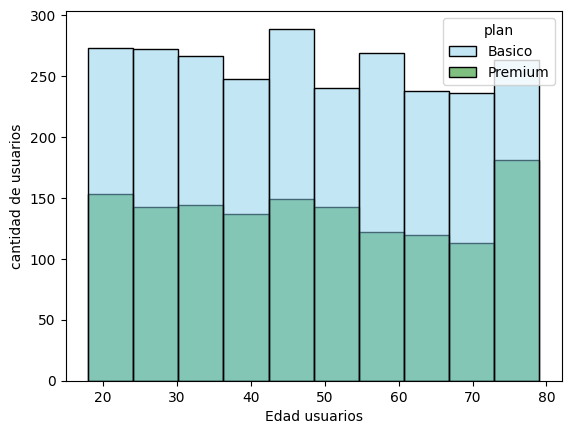

,count,mean,std,min,25%,50%,75%,max
plan,,,,,,,,
Basico,2595.0,48.025819,17.537967,18.0,33.0,47.0,63.0,79.0
Premium,1405.0,48.300356,17.973494,18.0,33.0,48.0,64.0,79.0


In [30]:

# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile,x="age",hue="plan",bins=10, palette=["skyblue","green"],edgecolor="black")
plt.xlabel('Edad usuarios')
plt.ylabel('cantidad de usuarios')
plt.show()
user_profile.groupby("plan")["age"].describe()

💡Insights: 
- Distribución ... se observa en histograma que la edad no es un factor que diferencie la relación entre los planes

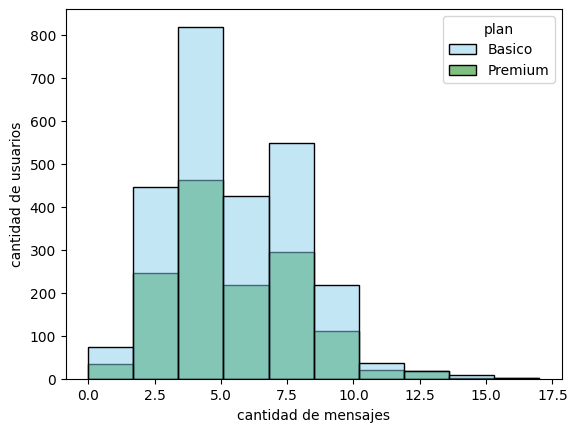

,count,mean,std,min,25%,50%,75%,max
plan,,,,,,,,
Basico,2595.0,48.025819,17.537967,18.0,33.0,47.0,63.0,79.0
Premium,1405.0,48.300356,17.973494,18.0,33.0,48.0,64.0,79.0


In [31]:

# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile,x="cant_mensajes",hue="plan",bins=10, palette=["skyblue","green"],edgecolor="black")
plt.xlabel('cantidad de mensajes')
plt.ylabel('cantidad de usuarios')
plt.show()
user_profile.groupby("plan")["age"].describe()


💡Insights: 
- Se observa un sesgo hacia la derecha lo cual indica que hay algunos usuarios que mandan mas mensajes en comparacion al resto y esto provoca un sesgoa la derecha.
- la mayor concentración de los usuarios mandan entre 3 y 8 mensajes,

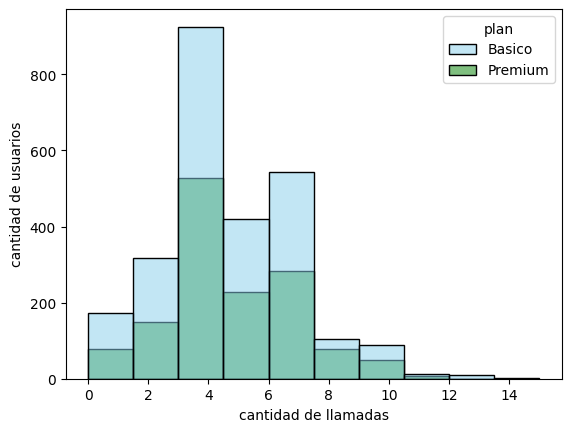

,count,mean,std,min,25%,50%,75%,max
plan,,,,,,,,
Basico,2595.0,48.025819,17.537967,18.0,33.0,47.0,63.0,79.0
Premium,1405.0,48.300356,17.973494,18.0,33.0,48.0,64.0,79.0


In [32]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile,x="cant_llamadas",hue="plan",bins=10, palette=["skyblue","green"],edgecolor="black")
plt.xlabel('cantidad de llamadas')
plt.ylabel('cantidad de usuarios')
plt.show()
user_profile.groupby("plan")["age"].describe()

💡Insights: 
- Distribución sesgada la derecha, algunos usuarios realizan mas llamadas que otros y esto hace que la distribucuón este sesgada a la derecha.
- La mayoria de los usuarios sin importar el plan realiza entre 3 y 7 llamadas.
- No se observa algun patron entre la cantidad de llamadas y el plan que poseen. solo que en proporcion hay mas usuarios con plan basico.

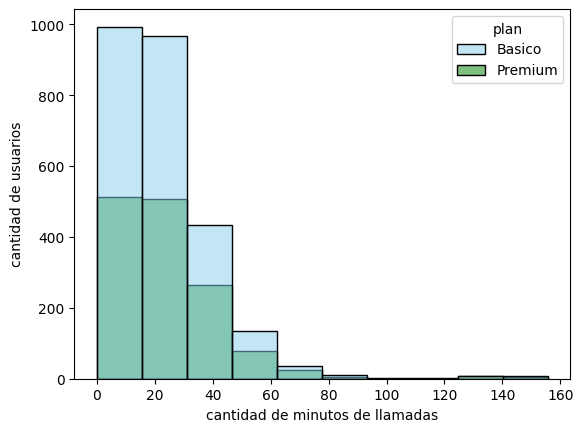

,count,mean,std,min,25%,50%,75%,max
plan,,,,,,,,
Basico,2595.0,48.025819,17.537967,18.0,33.0,47.0,63.0,79.0
Premium,1405.0,48.300356,17.973494,18.0,33.0,48.0,64.0,79.0


In [33]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile,x="cant_minutos_llamada",hue="plan",bins=10, palette=["skyblue","green"],edgecolor="black")
plt.xlabel('cantidad de minutos de llamadas')
plt.ylabel('cantidad de usuarios')
plt.show()
user_profile.groupby("plan")["age"].describe()

💡Insights: 
- Distribucón sesgada a la derecha debido a que un poco numero de usuarios realizan llamadas entre 120-150 minutos.
- la mayor cantidad de usuarios realiza llamadas entre 1 y 30 minutos, dominando aun así las llamadas cortas (de menos de un minuto a 18 miutos)
- la mayoria de los usurios tienen bajo consum de minutos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

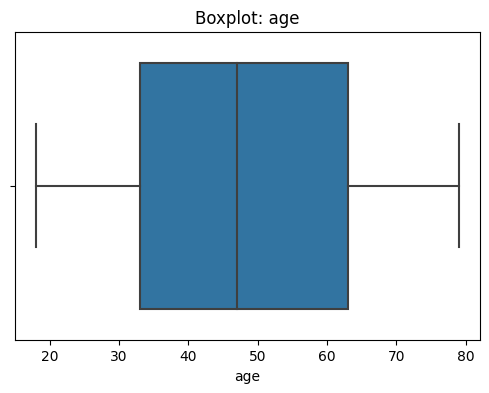

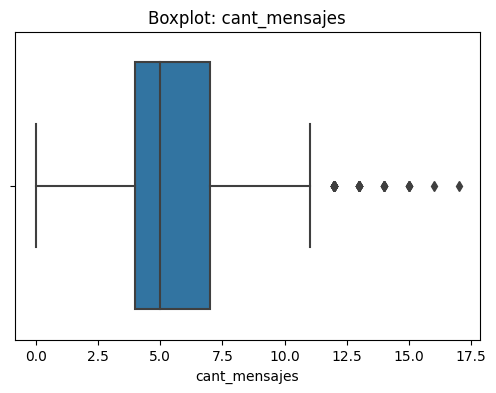

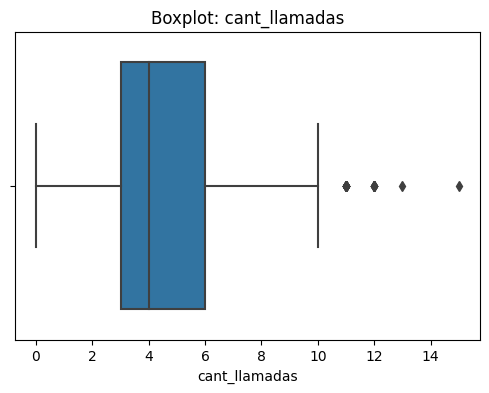

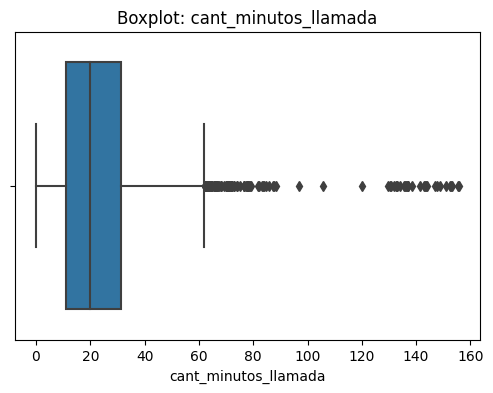

In [34]:
# Visualizando usando BoxPlot 

columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: no presenta outliers
- cant_mensajes: presenta pocos outliers
- cant_llamadas: presenta pocos outliers
- cant_minutos_llamada: presenta bastantes outliers con datos muy altos estan muy alejados deel extremos superior.

In [35]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for cols in columnas_limites:
    Q1 = user_profile[cols].quantile(0.25)
    Q2 = user_profile[cols].quantile(0.50)
    Q3 = user_profile[cols].quantile(0.75)

    IQR = Q3 - Q1

    upper = Q3 + 1.5 * IQR
    print("upper ",cols,":",upper)


user_profile[user_profile[cols] > upper].head()

upper  cant_mensajes : 11.5
upper  cant_llamadas : 10.5
upper  cant_minutos_llamada : 61.8575


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
27,10027,Ana,Gomez,28.0,MTY,2022,Premium,NaN,8.0,7.0,84.77
85,10085,Carlos,Ramirez,65.0,GDL,2022,Basico,NaN,6.0,5.0,152.36
93,10093,Ana,Torres,67.0,Medellín,2022,Basico,NaN,2.0,7.0,71.57
189,10189,Mariana,Torres,63.0,MTY,2022,Basico,NaN,9.0,4.0,155.42
198,10198,Sofia,Gomez,58.0,Medellín,2022,Basico,"1,73033E+18",8.0,9.0,78.77


In [36]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué? mantenemos los outliers debido a que representa un comportamiento real.
- cant_llamadas: mantener o no outliers, porqué? mantenemos los outliers debido a que representa un comportamiento real.
- cant_minutos_llamada: mantener o no outliers, porqué? mantenemos los outliers debido a que representa un comportamiento real y el valor se repite.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [37]:
# Crear columna grupo_uso
def clasificacion_uso(row):
    llamadas = row["cant_llamadas"]
    mensajes= row["cant_mensajes"]
    if llamadas<5 and mensajes<5:
        return "Bajo uso"
    elif llamadas<10 and mensajes<10:
        return "Uso medio"
    else:
        return "Alto uso"
user_profile["grupo_uso"]=user_profile.apply(clasificacion_uso, axis=1)
user_profile[["user_id","grupo_uso","cant_llamadas","cant_mensajes"]].head()

,user_id,grupo_uso,cant_llamadas,cant_mensajes
0,10000,Uso medio,3.0,7.0
1,10001,Alto uso,10.0,5.0
2,10002,Uso medio,2.0,5.0
3,10003,Alto uso,3.0,11.0
4,10004,Bajo uso,3.0,4.0


In [38]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [39]:

# Crear columna grupo_edad
def clasificacion_edad(row):
    edad = row["age"]
    if edad<30:
        return "Joven"
    elif edad<60:
        return "Adulto"
    else:
        return "Adulto mayor"
user_profile["grupo_edad"]=user_profile.apply(clasificacion_edad, axis=1)
user_profile[["user_id","age","grupo_edad"]].head()


,user_id,age,grupo_edad
0,10000,38.0,Adulto
1,10001,53.0,Adulto
2,10002,57.0,Adulto
3,10003,69.0,Adulto mayor
4,10004,63.0,Adulto mayor


In [40]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto mayor
4,10004,Mateo,Torres,63.0,GDL,2022,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

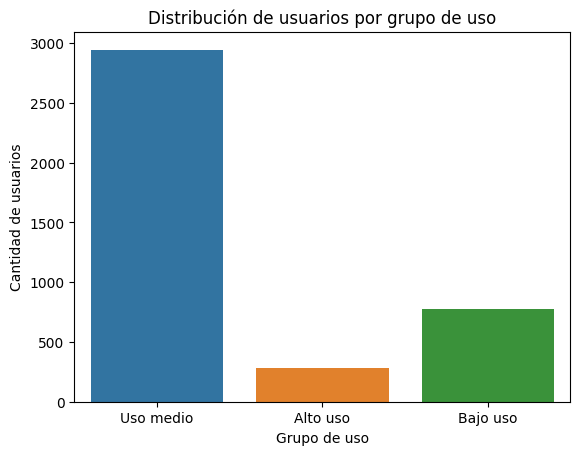

In [41]:
# Visualización de los segmentos por uso
sns.countplot(x="grupo_uso",data=user_profile)
plt.title("Distribución de usuarios por grupo de uso")
plt.xlabel("Grupo de uso")
plt.ylabel("Cantidad de usuarios")
plt.show()



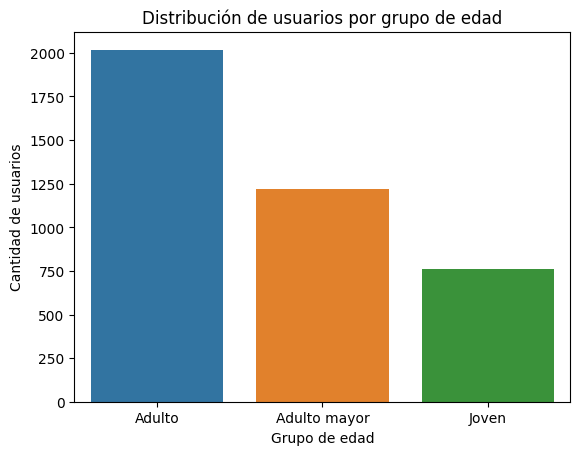

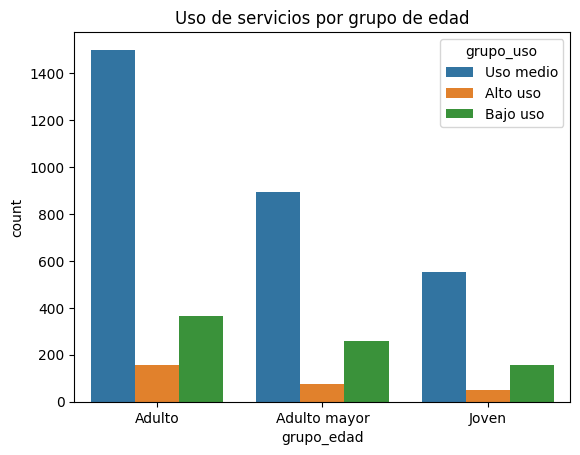

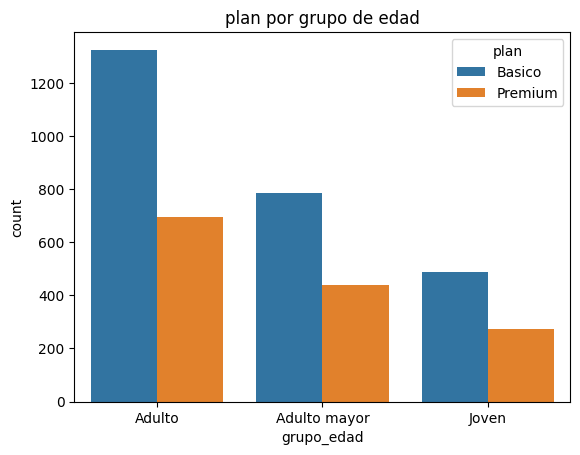

In [42]:
# Visualización de los segmentos por edad
sns.countplot(x="grupo_edad", data=user_profile)
plt.title("Distribución de usuarios por grupo de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Cantidad de usuarios")
plt.show()
# Visualización de los segmentos por edad y grupo de uso
sns.countplot(x="grupo_edad", hue="grupo_uso", data=user_profile)
plt.title("Uso de servicios por grupo de edad")
plt.show()
# Visualización de los segmentos por edad y plan
sns.countplot(x="grupo_edad", hue="plan", data=user_profile)
plt.title("plan por grupo de edad")
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
  Se tenian columnas con datos nulos, sentinels y outliers en los dataset de users y usage.  
    En los cuales se aplicaron distintos metodos:
    Los sentinels en colmna "age" se reemplazaron con la mediana para no afectar el analisis, otros se dejaron como nulos. Los de la columna city se dejaron como valores nulos.
    Los valores nulos de las columnas duration y length estaban justificados segun la columna "type".

    Porcentajes de nulos en columnas de users:
    churn_date con 88.35% 
    city con 11.72%

    Porcentajes de nulos en columnas de users:
    duration con 55.19% esto debido a que text no tiene duracion
    length con un 44.74% esto debido a que calls no lleva registro
    date con 1.25%
    
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  Se tienen 3 segmentos de clientes jovenes, adultos, adultos mayores.en los cuales el que tiene amyor concentración de usuarios es el de adulto, seguido de adulto mayor y por ultimo jovenes.
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
    Los segmentos mas valiosos para connectatel serian los adultos ya que cocentran la mayor cantidad de usuarios.
    Ademas tambien predomina el uso medio, este cocentra la mayor cantidad de usuarios. y por ultimo el tipo de plan, ya que, el plan basico es el que tiene mayor numero de usuarios.
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
    existen outlier en la cantidad de llamadas y mensajes, esto porvoca un pequeño sesgo hacia la derecha en los datos.
    pero el mas importante a considerar debe ser el de cantidad de minutos en llamada, este provoca un sesgo muy marcado en la distribucuón de datos. Hay muchos usuarios que realizan llamadas de mas de 60 minutos.

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
    Implementar capañas para cambio de plan de basico a premium a los usuarios de mayor concentracion (Adultos)
    Diseñar beneficios para los segmentos de edad que no son tan relevantes.

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se detectaron valores nulos en columnas del data set users y usage.
- Se detectaron sentinels en columna age en data set users.
- Se detectaron valores no validos en columna city de data set usage.
- Se detectaron fechas imposibles en date set users.


🔍 **Segmentos por Edad**
- El segmento Adulto concetra la mayor cocentración de usuarios 
- El grupo Adulto mayor representa un segmento relevante pero menor.
- Los Adultos presentan la mayor cantidad de usuarios Premium.


📊 **Segmentos por Nivel de Uso**
- Predomina el uso medio, que concentra la mayor cantidad de usuarios.
- El bajo uso representa el segundo grupo en tamaño.


➡️ Esto sugiere que el producto o servicio tiene mayor afinidad con usuarios en etapa laboral activa. Ademas que existen portunidades para incrementar la frecuencia o intensidad de uso.


💡 **Recomendaciones**
- El segmento adulto es el principal generador de volumen y valor, por lo que debe mantenerse como foco prioritario esto puede realizarse mediante la implementación campañas de upgrade de Básico a Premium, especialmente en usuarios adultos con uso medio o alto.
- Los jóvenes representan una oportunidad de crecimiento a largo plazo si se logra incrementar su participación esto puede realizarse diseñando beneficios específicos o planes adaptados para aumentar adopción, tambien integrando funcionalidades más digitales o sociales.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`